# Clasificador multi-label de prendas — bitácora de experimentos

**MIA-304 Computer Vision · UdeSA**
Hernán Marano · Jorge Federico Flores · Nicolás Velázquez
Repositorio: [UdeSA-computer-vision](https://github.com/MatLock/UdeSA-computer-vision)

Este notebook registra los experimentos hechos sobre el clasificador
multi-label que vive en `deep-tagger-api/deep_learning/`.

## Contexto

El repo ya tiene un clasificador *single-label* TinyVGG entrenado sobre
Fashion-MNIST que devuelve "qué prenda es" entre 10 clases. Lo que falta
es un modelo que devuelva atributos descriptivos (estilo de cuello, fit,
ocasión, temporada, detalles de bolsillos, etc.) sobre los CSV reales del
catálogo en `img-puller/data/`. El nuevo modelo coexiste con el actual,
no lo reemplaza.

**Restricciones de diseño**

- Una arquitectura, tres entrenamientos independientes (uno por
  `tops`, `shoes`, `pants`).
- Soporte CPU/GPU vía flag `--device {cpu, cuda, auto}`.
- Cada modelo produce su propio `.pth` y `.labels.json`.

El código del entrenamiento vive en
[train_multilabel.py](../deep_learning/train_multilabel.py).


## Setup

Las celdas de código del notebook leen los `.labels.json` de los modelos
en disco y los CSV originales. Si re-entrenás los modelos, las tablas y
gráficos se actualizan al re-ejecutar.

> **Si te tira `ModuleNotFoundError`** al ejecutar la primera celda:
> el kernel actual no tiene los paquetes necesarios. La celda siguiente
> los instala automáticamente en el Python del kernel — no hace falta
> reconfigurar nada, sólo ejecutarla y re-ejecutar las posteriores.


In [53]:
# Auto-fix de dependencias: instala lo que falte EN EL PYTHON DEL KERNEL
# actual, sin importar si es el venv del API o un Python global.
import sys

print("Python del kernel:", sys.executable)

_required = ["matplotlib", "pandas", "scikit-learn"]
_missing = []
for _pkg in _required:
    _import_name = "sklearn" if _pkg == "scikit-learn" else _pkg
    try:
        __import__(_import_name)
    except ModuleNotFoundError:
        _missing.append(_pkg)

if _missing:
    print(f"\nFaltan: {_missing}. Instalando en este kernel...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", *_missing])
    print("\nListo. Re-ejecutá esta celda y las siguientes.")
else:
    print("\nDependencias OK.")


Python del kernel: c:\Maestria\MIA_304\UdeSA-computer-vision\deep-tagger-api\.venv\Scripts\python.exe

Dependencias OK.


In [54]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name and not (REPO_ROOT / "img-puller").exists():
    REPO_ROOT = REPO_ROOT.parent
print("repo root:", REPO_ROOT)

TORCH_STATE = REPO_ROOT / "deep-tagger-api" / "deep_learning" / "torch_state"
CSV_DIR     = REPO_ROOT / "img-puller" / "data"

PRODUCT_TYPES = ["tops", "shoes", "pants"]
SCHEMA = {
    "tops":  ["neck_style", "fit_silhouette", "season"],
    "shoes": ["wearing_occasion", "style_silhouette", "season"],
    "pants": ["pocket_details", "fit_silhouette", "season"],
}


repo root: C:\Maestria\MIA_304\UdeSA-computer-vision


## Datos

Imágenes RGB 224×224 ya descargadas y re-escaladas por `img-puller`.
Cada tipo tiene su propio CSV con atributos categóricos distintos.


In [55]:
rows = []
for t in PRODUCT_TYPES:
    csv_path = CSV_DIR / f"{t}_tags.csv"
    df = pd.read_csv(csv_path)
    df = df.loc[:, ~df.columns.duplicated()]
    img_dir = CSV_DIR / "images" / t
    n_imgs = len(list(img_dir.glob("*.jpg"))) if img_dir.exists() else 0
    rows.append({
        "tipo": t,
        "atributos": ", ".join(SCHEMA[t]),
        "filas CSV": len(df),
        "imgs en disco": n_imgs,
    })

pd.DataFrame(rows).set_index("tipo")


,atributos,filas CSV,imgs en disco
tipo,,,
tops,"neck_style, fit_silhouette, season",36173,32506
shoes,"wearing_occasion, style_silhouette, season",17281,17295
pants,"pocket_details, fit_silhouette, season",7149,7149


### EDA: distribución de clases

Las distribuciones por atributo son muy desbalanceadas. Los tres valores
más frecuentes de `neck_style` (tops) cubren ~67% del dataset; al final
de la cola hay clases con 1-3 ejemplos. Patrón parecido en los demás
tipos.


In [56]:
for t in PRODUCT_TYPES:
    df = pd.read_csv(CSV_DIR / f"{t}_tags.csv")
    df = df.loc[:, ~df.columns.duplicated()]
    print(f"\n=== {t} ===")
    for attr in SCHEMA[t]:
        counts = df[attr].value_counts(dropna=True)
        cobertura_top3 = counts.head(3).sum() / len(df)
        print(f"  {attr}: {len(counts)} clases únicas; top-3 cubre {cobertura_top3:.0%} del dataset")
        print(f"    top:    {dict(counts.head(3))}")
        if len(counts) > 5:
            print(f"    bottom: {dict(counts.tail(3))}")



=== tops ===
  neck_style: 31 clases únicas; top-3 cubre 62% del dataset
    top:    {'Crew-Neck': np.int64(8715), 'V-Neck': np.int64(7551), 'Collared-Neck': np.int64(6199)}
    bottom: {'Criss-Cross-Neck': np.int64(4), 'Baseball-Collar': np.int64(3), 'Illusion-Neck': np.int64(2)}
  fit_silhouette: 7 clases únicas; top-3 cubre 98% del dataset
    top:    {'Relaxed-Fit': np.int64(26551), 'Tailored-Fit': np.int64(5340), 'Fitted': np.int64(3398)}
    bottom: {'Classic-Fit': np.int64(34), 'Oversize': np.int64(17), 'Modern-Fit': np.int64(2)}
  season: 4 clases únicas; top-3 cubre 96% del dataset
    top:    {'Spring': np.int64(12846), 'Fall': np.int64(12532), 'Tropical-Vacation': np.int64(9270)}

=== shoes ===
  wearing_occasion: 21 clases únicas; top-3 cubre 78% del dataset
    top:    {'Casual': np.int64(5976), 'Day-Party': np.int64(5961), 'Work': np.int64(1620)}
    bottom: {'Activewear': np.int64(2), 'Tennis-Sports': np.int64(1), 'Hunting-Outdoor_Activity': np.int64(1)}
  style_silhoue

### Decisión: filtrar clases con `<20` ejemplos

**Pregunta**: ¿qué hacer con clases que tienen menos ejemplos que el
tamaño esperado del val set?

Con split 90/10 y datasets de 7k–32k filas, una clase con menos de 20
ejemplos puede aparecer 0 o 1 veces en val, lo que produce F1 nulo o
saturado por azar. El umbral 20 es prudencial: subirlo a 100 elevaría
`f1_macro` reportado por puro recorte de denominador, sin mejorar el
modelo.

**Implementación** en `train_multilabel.py:load_and_filter`:

1. Se cuenta la frecuencia por clase en cada atributo.
2. Las clases con `count < 20` quedan fuera de los logits.
3. Las celdas afectadas se marcan como `NaN` pero la fila queda si
   tiene valores válidos en otros atributos.
4. Sólo se descarta la fila si pierde *todos* los atributos.
5. Después se hace shuffle (seed=42) y se aplica el cap `--max-samples`.


In [57]:
MIN_SAMPLES = 20
filter_rows = []
for t in PRODUCT_TYPES:
    df = pd.read_csv(CSV_DIR / f"{t}_tags.csv")
    df = df.loc[:, ~df.columns.duplicated()]
    for attr in SCHEMA[t]:
        counts = df[attr].value_counts(dropna=True)
        keep = counts[counts >= MIN_SAMPLES]
        drop = counts[counts < MIN_SAMPLES]
        filter_rows.append({
            "tipo": t,
            "atributo": attr,
            "únicas en CSV": len(counts),
            "tras filtro": len(keep),
            "descartadas": ", ".join(f"{c}({n})" for c, n in drop.items()) or "—",
        })

pd.DataFrame(filter_rows)


,tipo,atributo,únicas en CSV,tras filtro,descartadas
0,tops,neck_style,31,26,"Shawl-Collar(11), Ballet-Neck(6), Criss-Cross-..."
1,tops,fit_silhouette,7,5,"Oversize(17), Modern-Fit(2)"
2,tops,season,4,4,—
3,shoes,wearing_occasion,21,13,"Running-Sports(9), Sports(8), Surfing_Swimming..."
4,shoes,style_silhouette,39,30,"Work-Boots(19), Ballet(17), Gladiators(15), De..."
5,shoes,season,4,4,—
6,pants,pocket_details,14,11,"Rounded-Stitched-Pocket(7), Cargo-Pocket(5), I..."
7,pants,fit_silhouette,11,5,"Relaxed-Fit(11), Classic-Fit(10), Skinny-Fit(9..."
8,pants,season,4,4,—


## Configuración base (compartida por todos los experimentos)

| Componente | Valor |
|---|---|
| Backbone | `torchvision.models.resnet18` |
| Cabeza | `Linear(512, n_logits)` con sigmoide implícito en la loss |
| Loss | `BCEWithLogitsLoss` |
| Optimizer | `Adam` |
| Scheduler | `CosineAnnealingLR(T_max=epochs)` |
| Augmentation (train) | `RandomHorizontalFlip(0.5)` + `ColorJitter(0.1)` |
| Augmentation (val) | ninguna |
| Normalización | mean/std de ImageNet |
| Split | 90% train / 10% val (seed=42) |
| Métrica de selección | `val_f1_macro` (mejor checkpoint guardado) |

Lo que **cambia entre experimentos**: pesos iniciales del backbone,
cantidad de imágenes (cap), `--epochs`, `--lr`, augmentation y optimizer.
Los demás parámetros se mantienen fijos.

**Métricas reportadas en cada experimento**:

- `f1_micro` — F1 agregado tratando todas las etiquetas como un pool de
  positivos.
- `f1_macro` — F1 promediado sin pesos por clase. Sensible al
  desbalance. Es la métrica de selección de checkpoint.
- `subset_acc` — fracción de ejemplos con los **3** atributos correctos
  a la vez.
- `top1_avg` — promedio de top-1 accuracy por atributo. Es lo más
  cercano a "accuracy" en sentido tradicional.


## Experimentos

Cada experimento sigue el mismo patrón:

> **Pregunta** — qué quiere responder.
> **Cambio respecto al anterior** — diff conciso de hiperparámetros.
> **Resultado** — tabla de métricas en val.
> **Observación** — qué muestran los números.
> **Decisión** — qué se hace con el aprendizaje.

Los experimentos están numerados de manera secuencial (E1, E2, ...) y se
agregan al final del notebook a medida que se corren nuevos.


### E1 — ResNet18 *from scratch* (baseline)

**Pregunta:** ¿qué rendimiento se obtiene sin pesos preentrenados ni
todo el dataset?

**Cambio respecto al anterior:** —  (es el punto de partida)

**Configuración:**

| Parámetro | Valor |
|---|---|
| Backbone | `resnet18(weights=None)` |
| Dataset | tops, `--max-samples 10000` |
| Optimizer | `Adam(lr=1e-3)` |
| Epochs / Batch | 10 / 64 |

**Resultado:**

| Métrica | Valor |
|---|---:|
| best `val_f1_macro` | **0.2406** |
| `val_f1_micro` (último epoch) | 0.6822 |
| `val_subset_acc` (último epoch) | 0.1960 |
| `train_loss` / `val_loss` (último epoch) | 0.109 / 0.122 |

**Observación:** `train ≈ val` → no hay overfit, pero `f1_macro=0.24`
indica que el modelo no aprende clases minoritarias (muchas con F1=0).
Con 9k imgs y sin features pre-aprendidas, ResNet18 no consigue armar
representaciones útiles para 26+ clases de cuello.

**Decisión:** activar pretrained ImageNet y sacar el cap de 10k.


### E2 — Pretrained ImageNet + dataset completo

**Pregunta:** ¿cuánto suma transfer learning + más datos?

**Cambio respecto a E1:**

- `weights=ResNet18_Weights.IMAGENET1K_V1` (era `None`).
- `--max-samples 0` (era 10000) → 32503 imgs.
- `lr=3e-4` (era 1e-3) — pesos preentrenados necesitan magnitud menor
  para no "olvidar".
- `batch=128` (era 64) — para usar la VRAM disponible.

**Resultado:**

| Métrica | E1 | E2 | Δ |
|---|---:|---:|---:|
| best `val_f1_macro` | 0.2406 | **0.5227** | **+28.2 pts** |
| `val_f1_micro` (último) | 0.6822 | 0.7897 | +10.7 pts |
| `val_subset_acc` (último) | 0.1960 | 0.4292 | +23.3 pts |
| `train_loss` / `val_loss` | 0.109 / 0.122 (gap 1.1×) | 0.014 / 0.106 (gap **8×**) | overfit declarado |

**Observación:** salto fuerte en las 3 métricas. Aparece overfit (gap
8×). El checkpoint que se guarda es el del mejor val, así que el gap en
sí no afecta al modelo final, pero queda abierta la pregunta de si hay
margen para ganar más cerrándolo.

**Decisión:** quedarse con esta config y probar regularización para ver
si cerrar el gap mejora val.


### E3 — Regularización (AdamW + augmentation fuerte)

**Pregunta:** ¿cerrar el gap train/val mejora la métrica de selección?

**Cambio respecto a E2:**

- `Adam` → `AdamW(weight_decay=1e-4)`.
- Augmentation train: agregado `RandomResizedCrop(0.85-1.0)`,
  `RandomRotation(±10°)`, `ColorJitter(0.2, hue=0.05)`.

**Resultado:**

| Métrica | E2 | E3 | Δ |
|---|---:|---:|---:|
| best `val_f1_macro` | **0.5227** | 0.5103 | **−1.2 pts** |
| `val_f1_micro` (último) | 0.7897 | 0.7945 | +0.5 pts |
| `val_subset_acc` (último) | 0.4292 | 0.4363 | +0.7 pts |
| `train_loss` / `val_loss` | 0.014 / 0.106 (gap 8×) | 0.050 / 0.086 (gap **1.7×**) | gap colapsado |

**Observación:** el gap se cerró como esperaba la teoría (8× → 1.7×) y
`val_loss` bajó. Pero `f1_macro` (la métrica de selección) **bajó
1.2 pts**. El best apareció antes del epoch 10 (0.5103 → 0.5018), señal
de que el modelo ya convergió y empieza a empeorar.

**Decisión:** descartar AdamW + aug fuerte en datasets grandes. Volver
a la config de E2 para los entrenamientos finales por tipo.

**Aprendizaje general:** el gap train/val es síntoma, no causa.
Regularizar para cerrarlo sin diagnóstico previo puede empeorar val.

### Aplicar E2 a los 3 tipos

Adoptada la config de E2, se hizo una corrida sobre los 3 tipos. Las tres curvas mostraron regímenes distintos, lo que motivó usar **un número distinto de epochs por tipo**.


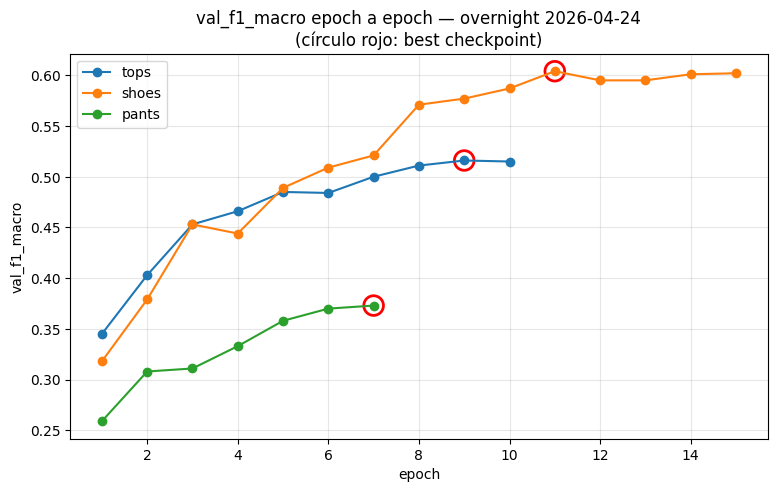

In [58]:
curves = {
    "tops":  [0.345, 0.403, 0.453, 0.466, 0.485, 0.484, 0.500, 0.511, 0.516, 0.515],
    "shoes": [0.318, 0.379, 0.453, 0.444, 0.489, 0.509, 0.521, 0.571, 0.577, 0.587, 0.604, 0.595, 0.595, 0.601, 0.602],
    "pants": [0.259, 0.308, 0.311, 0.333, 0.358, 0.370, 0.373],
}
best_epochs = {"tops": 9, "shoes": 11, "pants": 7}

fig, ax = plt.subplots(figsize=(9, 5))
for t, vals in curves.items():
    epochs = list(range(1, len(vals) + 1))
    ax.plot(epochs, vals, marker="o", label=t)
    be = best_epochs[t]
    ax.scatter([be], [vals[be - 1]], s=200, edgecolors="red", facecolors="none", linewidths=2)

ax.set_xlabel("epoch")
ax.set_ylabel("val_f1_macro")
ax.set_title("val_f1_macro epoch a epoch — overnight 2026-04-24\n(círculo rojo: best checkpoint)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


**Pregunta:** ¿con la config de E2, en cuántos epochs converge tops?

**Resultado:**

| Métrica | tops |
|---|---:|
| best `val_f1_macro` | **0.5164** |
| `val_f1_micro` | 0.7862 |
| `val_subset_acc` | 0.4120 |
| `val_top1_avg` | 0.7875 |
| best epoch | 9 / 10 |
| Duración | 11:22 |

**Top-1 por atributo** (val):

| Atributo | top-1 |
|---|---:|
| `neck_style` | 0.7799 |
| `fit_silhouette` | 0.8787 |
| `season` | **0.7040** |

**Observación:** `f1_macro` peakea en epoch 9, después oscila chiquito
hacia abajo. Modelo convergido. `season=0.70` es contraintuitivo: con
sólo 4 clases es el atributo *más débil*, por debajo de `neck_style`
(26 clases). La hipótesis es que "Spring" y "Fall" son visualmente
similares en fotos de catálogo.

**Decisión:** mantener 10 epochs. Diferencia ±1 pt vs corridas previas
del mismo experimento es ruido cuDNN normal (kernels no determinísticos).


### E4 — Entrenar shoes con mas epochs

**Pregunta:** una corrida previa con 10 epochs había peakeado en el
último. ¿Cuántos epochs necesita shoes para entrar en plateau?

**Cambio:** `--epochs 15` (era 10 en el baseline de shoes de la sección «Aplicar E2 a los 3 tipos»).

**Resultado:**

| Métrica | shoes |
|---|---:|
| best `val_f1_macro` | **0.6044** (vs 0.5533 con 10 epochs) |
| `val_f1_micro` | 0.8209 |
| `val_subset_acc` | 0.4954 |
| `val_top1_avg` | 0.8243 |
| best epoch | 11 / 15 |
| Duración | 13:11 |

**Top-1 por atributo** (val):

| Atributo | top-1 |
|---|---:|
| `wearing_occasion` | 0.7936 |
| `style_silhouette` | 0.7772 |
| `season` | **0.9022** |

**Observación:** best en epoch 11; los últimos 4 epochs oscilan en
0.595-0.602. **+5.1 pts vs 10 epochs**. `season=0.90` es el atributo
más fuerte del sistema entero — botas vs sandalias es señal clara de
temporada.

**Decisión:** mantener 15 epochs para shoes. Ir a 20 sería desperdicio.


### E5 — Entrenar pants con menos epochs

**Pregunta:** una corrida previa de 10 epochs mostró `val_loss` mínimo
en epoch 3 con tendencia ascendente. ¿Capando en 7 se evita ese overfit
y se mejora val?

**Cambio:** `--epochs 7` (era 10 en el baseline de pants de la sección «Aplicar E2 a los 3 tipos»).

**Resultado:**

| Métrica | pants |
|---|---:|
| best `val_f1_macro` | **0.3726** (vs 0.4156 con 10 epochs antes) |
| `val_f1_micro` | 0.6774 |
| `val_subset_acc` | 0.1709 |
| `val_top1_avg` | 0.6812 |
| best epoch | 7 / 7 (último) |
| Duración | 3:07 |

**Top-1 por atributo** (val):

| Atributo | top-1 |
|---|---:|
| `pocket_details` | **0.4318** |
| `fit_silhouette` | 0.7743 |
| `season` | 0.8375 |

**Observación:** −4.3 pts vs la corrida previa de 10 epochs. La curva
de `val_f1_macro` era monotónicamente creciente al epoch 7, no había
peakeado. El criterio de cap basado en `val_loss` mínimo era el
incorrecto: en pants, `val_loss` y `val_f1_macro` **no co-evolucionan**
(la primera sube mientras la segunda sigue mejorando).

**Decisión:** descartar el cap de 7. Re-correr pants con más epochs (E6).

**Aprendizaje general:** el criterio para cuántos epochs correr debe ser
la métrica de selección (`val_f1_macro`), no `val_loss`.


### E6 — Entrenar pants con mas epochs

**Pregunta:** ¿con 15 epochs pants entra en plateau?

**Cambio respecto a E5:** `--epochs 15` (era 7).

**Resultado:**

| Métrica | E5 (7 ep) | E6 (15 ep) | Δ |
|---|---:|---:|---:|
| best `val_f1_macro` | 0.3726 | **0.4094** | **+3.7 pts** |
| `val_f1_micro` | 0.6774 | 0.6815 | +0.4 pts |
| `val_subset_acc` | 0.1709 | 0.2017 | +3.1 pts |
| `val_top1_avg` | 0.6812 | 0.6831 | +0.2 pts |
| best epoch | 7 / 7 | 11 / 15 | — |

**Top-1 por atributo** (val):

| Atributo | E5 | E6 |
|---|---:|---:|
| `pocket_details` | 0.4318 | **0.4402** |
| `fit_silhouette` | 0.7743 | 0.7701 |
| `season` | 0.8375 | 0.8389 |

**Curva `val_f1_macro` epoch a epoch:**

```
0.258 → 0.297 → 0.322 → 0.330 → 0.340 → 0.374 → 0.397 → 0.382 → 0.405 → 0.408 → 0.409 → 0.398 → 0.404 → 0.405 → 0.403
                                                                                  ↑ best (epoch 11)
```

**Observación:** best en epoch 11, los últimos 4 epochs oscilan en
0.398–0.405 (plateau). 15 epochs alcanzaron — ir a 20 no ayudaría.
La mejora vs E5 es +3.7 pts en `f1_macro` y +3 pts en `subset_acc`,
con cambios menores en las demás métricas. `pocket_details` (el atributo
visualmente más sutil) sigue siendo el más débil del sistema (0.44),
con +0.8 pts respecto a E5.

**Decisión:** adoptar `--epochs 15` para pants. Confirma el aprendizaje
de E5 (la métrica de selección, no `val_loss`, marca cuándo parar).


### E7 — Compensar desbalance de clases con `pos_weight`

**Pregunta:** ¿`pos_weight` (ponderación inversa por frecuencia en
`BCEWithLogitsLoss`) sube `f1_macro` como predijo el diagnóstico de F1
por clase? ¿A qué costo en las otras métricas?

**Cambio respecto al baseline de cada tipo** (baseline de tops en «Aplicar E2 a los 3 tipos», E4 para shoes, E6 para pants):

- `BCEWithLogitsLoss(pos_weight=...)` con
  `pos_weight_i = (#neg_i / #pos_i)`, clamped a 20.0.
- Pesos efectivos por modelo (de los logs):

| Tipo | min | mean | max |
|---|---:|---:|---:|
| tops  | 0.36 | 15.58 | 20.00 (capped) |
| shoes | 0.37 | 16.64 | 20.00 (capped) |
| pants | 0.69 | 11.49 | 20.00 (capped) |

El cap binding en `max=20.00` indica que las clases más raras hubieran
recibido pesos aún mayores sin el cap.

**Resultado — agregado:**

| Métrica | tops antes → después | shoes antes → después | pants antes → después |
|---|---|---|---|
| `val_f1_macro` | 0.5143 → **0.5745** (+6.0) | 0.6063 → **0.6656** (+5.9) | 0.4094 → **0.4694** (+6.0) |
| `val_f1_micro` | 0.7869 → 0.7873 (≈) | 0.8225 → 0.8120 (−1.0) | 0.6815 → 0.6424 (−3.9) |
| `val_subset_acc` | 0.4240 → 0.3631 (**−6.1**) | 0.5093 → 0.4138 (**−9.6**) | 0.2017 → 0.1064 (**−9.5**) |
| `val_top1_avg` | 0.7871 → 0.7884 (≈) | 0.8216 → 0.8154 (−0.6) | 0.6831 → 0.6541 (−2.9) |
| best epoch | 9/10 → 9/10 | 15/15 → 12/15 | 11/15 → 7/15 |

**Resultado — top-1 por atributo:**

| Modelo / atributo | antes | después | Δ |
|---|---:|---:|---:|
| tops `neck_style` | 0.7799 | 0.7873 | +0.7 |
| tops `fit_silhouette` | 0.8833 | 0.8642 | −1.9 |
| tops `season` | 0.6982 | 0.7135 | +1.5 |
| shoes `wearing_occasion` | 0.7954 | 0.7838 | −1.2 |
| shoes `style_silhouette` | 0.7621 | 0.7638 | ≈ |
| shoes `season` | 0.9074 | 0.8987 | −0.9 |
| pants `pocket_details` | 0.4402 | 0.4332 | −0.7 |
| pants `fit_silhouette` | 0.7701 | 0.7362 | −3.4 |
| pants `season` | 0.8389 | 0.7927 | −4.6 |

**Resultado — clases que más subieron / bajaron en F1**:

`tops.neck_style` (la más ilustrativa):

| Clase | sup | F1 antes | F1 después | Δ |
|---|---:|---:|---:|---:|
| Asymmetrical-Collar | 8 | 0.000 | 0.556 | **+55.6** |
| Sweetheart-Neck | 6 | 0.000 | 0.500 | **+50.0** |
| Cowl-Neck | 33 | 0.468 | 0.635 | +16.7 |
| Front-Keyhole | 16 | 0.417 | 0.552 | +13.5 |
| Band-Collar | 49 | 0.458 | 0.556 | +9.8 |
| Stand-Collar | 64 | 0.605 | 0.667 | +6.2 |
| ... | | | | |
| Notched-Collar | 82 | 0.810 | 0.746 | −6.4 |
| Collared-Neck | 533 | 0.878 | 0.860 | −1.8 |

`shoes.style_silhouette`:

| Clase | sup | F1 antes | F1 después | Δ |
|---|---:|---:|---:|---:|
| Moccasin | 11 | 0.167 | 0.500 | **+33.3** |
| High-Top-Sneakers | 8 | 0.400 | 0.667 | **+26.7** |
| Chukka-Boots | 10 | 0.571 | 0.778 | **+20.7** |
| Smoking-Flats | 14 | 0.600 | 0.800 | **+20.0** |
| Espadrilles | 19 | 0.429 | 0.579 | +15.0 |
| Motorcycle-Boots | 16 | 0.593 | 0.706 | +11.3 |
| ... | | | | |
| Combat-Boots | 78 | 0.899 | 0.851 | −4.8 |
| Flats | 37 | 0.693 | 0.637 | −5.6 |

`shoes.season` — el caso paradigmático:

| Clase | sup | F1 antes | F1 después | Δ |
|---|---:|---:|---:|---:|
| Spring | 65 | 0.257 | 0.490 | **+23.3** |
| Fall | 1301 | 0.961 | 0.957 | ≈ |
| Tropical-Vacation | 281 | 0.869 | 0.868 | ≈ |
| Cold_Weather-Vacation | 81 | 0.559 | 0.541 | −1.8 |

`pants.pocket_details` (el atributo más débil del sistema):

| Clase | sup | F1 antes | F1 después | Δ |
|---|---:|---:|---:|---:|
| Welt-Pocket | 70 | 0.234 | 0.386 | **+15.2** |
| Slant-Pocket | 64 | 0.080 | 0.226 | **+14.6** |
| Pockets (mayoritaria) | 264 | 0.478 | 0.558 | **+8.0** |
| Zipper-Pocket | 70 | 0.397 | 0.427 | +3.0 |
| Patch-Pocket | 58 | 0.308 | 0.317 | +0.9 |
| Button-Pocket | 13 | 0.222 | 0.190 | −3.2 |

**Observación:**

1. **`pos_weight` cumplió con la teoría sobre `f1_macro`**: +6 pts en los
   tres modelos, **a la cota alta del rango estimado** (+2 a +5 pts).
2. **El trade-off real es `subset_acc`, no `f1_micro`**: −6 a −10 pts.
   `f1_micro` se mantuvo o cayó poco. La razón intuitiva: `pos_weight`
   hace al modelo más agresivo prediciendo positivos, así que es más
   probable que dentro de un grupo prediga *múltiples* etiquetas
   simultáneamente, lo que rompe el "exact-match" de `subset_acc`.
3. **Las clases medias (sup 30-150) son las grandes ganadoras**:
   Moccasin/High-Top-Sneakers/Chukka-Boots en shoes, Cowl-Neck/Front-Keyhole
   en tops, Welt-Pocket/Slant-Pocket en pants. Subieron 10-30 puntos de F1.
4. **Algunas clases mayoritarias cedieron levemente** (1-5 pts): el peso
   relativo bajó, era el costo esperado.
5. **Clases muy raras (sup ≤8)**:
   - Algunas se "rescataron" (Asymmetrical-Collar 0→0.56, Sweetheart-Neck
     0→0.50). Esto es **señal frágil** — son F1 calculados sobre 6-8
     ejemplos, alta varianza.
   - Otras siguen en 0 (Pleated-Neck, Boat-Neck, Mandarin-Collar-Neck,
     Peter-Pan-Collar, Inner-Pocket). Son irrecuperables sin más datos.
6. **`pants` peakeó muy temprano (epoch 7/15)** y `val_loss` voló (0.23 →
   0.91). El modelo se vuelve sobreajustado mucho más rápido con
   `pos_weight` cuando el dataset es chico. **15 epochs es mucho con
   pos_weight para pants**; con 8-10 alcanzaría.
7. **El caso `Spring` en shoes es el ejemplo de libro**: 0.26 → 0.49 con
   los mismos 65 ejemplos, sólo cambiando cómo se ponderaba la loss.

**Decisión:**

Adoptar `--pos-weight` como **default** para entrenamientos futuros si la
métrica de producto es `f1_macro` o "qué tan bien predice clases raras".
**Rechazar** si la métrica de producto es `subset_acc` (ej. una API que
sólo es útil cuando los **3** atributos están perfectos a la vez) — ahí
el baseline gana.

Para esta entrega académica el cambio queda activo (los `.pth` actuales
en disco son post-pos_weight). El notebook documenta ambas configuraciones
para que se vea el trade-off.

**Aprendizaje general:** una intervención de loss puede mover una métrica
agregada (+6 pts en `f1_macro`) mientras empuja otras hacia abajo (−9 pts
en `subset_acc`). **No hay free lunch** — sólo elecciones explícitas
sobre qué se está optimizando.


## Estado actual

Datos de los `.pth` actualmente en disco. Re-ejecutar las celdas tras
correr nuevos experimentos para que las tablas se actualicen solas.


In [59]:
# Tabla resumen leída del .labels.json de cada modelo en disco. Si re-entrenás
# alguno, los números de esta tabla se actualizan al re-ejecutar.
def _load(t):
    return json.loads((TORCH_STATE / f"multilabel_classifier_{t}_v1.labels.json").read_text(encoding="utf-8"))

_rows = []
for t in PRODUCT_TYPES:
    lf = _load(t)
    bv = lf["best_val"]
    cli = lf.get("trained_with", {}).get("args", {}) or {}
    _rows.append({
        "tipo": t,
        "epochs": cli.get("epochs", "?"),
        "best epoch": lf.get("best_epoch", "?"),
        "n_logits": lf["num_logits"],
        "f1_macro": round(bv["val_f1_macro"], 4),
        "f1_micro": round(bv["val_f1_micro"], 4),
        "subset_acc": round(bv["val_subset_acc"], 4),
        "top1_avg": round(bv["val_top1_avg"], 4),
    })

pd.DataFrame(_rows).set_index("tipo")


,epochs,best epoch,n_logits,f1_macro,f1_micro,subset_acc,top1_avg
tipo,,,,,,,
tops,10,9,35,0.5745,0.7873,0.3631,0.7884
shoes,15,12,47,0.6656,0.8120,0.4138,0.8154
pants,15,7,20,0.4694,0.6424,0.1064,0.6541


### Top-1 accuracy por atributo

La tabla de arriba reporta `f1_macro`, `f1_micro` y `subset_acc`:
métricas multi-label honestas pero poco intuitivas para alguien que no
trabaja con ellas a diario. Para responder *"¿cuán seguido el modelo
acierta el atributo correcto?"*, la métrica más natural es **top-1
accuracy por atributo**: dentro de cada grupo de logits (p. ej. los 26
logits de `neck_style`), qué fracción del val tiene el `argmax`
correcto.

Es el equivalente más cercano a "accuracy" en sentido tradicional, y
expone además qué atributos son más fáciles o más difíciles dentro de
cada modelo (p. ej. en tops, `season` resulta más difícil que
`fit_silhouette` aunque tenga menos clases).

Los datos se cargan del `.labels.json` real de cada modelo.


In [60]:
def load_labels(t: str) -> dict:
    p = TORCH_STATE / f"multilabel_classifier_{t}_v1.labels.json"
    return json.loads(p.read_text(encoding="utf-8"))

label_files = {t: load_labels(t) for t in PRODUCT_TYPES}

summary_rows = []
for t, lf in label_files.items():
    bv = lf["best_val"]
    top1 = bv["val_top1_per_group"]
    summary_rows.append({
        "tipo": t,
        "n_logits": lf["num_logits"],
        "best_epoch": lf["best_epoch"],
        "f1_micro": bv["val_f1_micro"],
        "f1_macro": bv["val_f1_macro"],
        "subset_acc": bv["val_subset_acc"],
        "top1_avg": bv["val_top1_avg"],
        "top1 por atributo": ", ".join(f"{a}={v:.2f}" for a, v in top1.items()),
    })

pd.DataFrame(summary_rows).set_index("tipo")


,n_logits,best_epoch,f1_micro,f1_macro,subset_acc,top1_avg,top1 por atributo
tipo,,,,,,,
tops,35,9,0.787268,0.574494,0.363077,0.788361,"neck_style=0.79, fit_silhouette=0.86, season=0.71"
shoes,47,12,0.811993,0.665561,0.413773,0.815437,"wearing_occasion=0.78, style_silhouette=0.76, ..."
pants,20,7,0.642409,0.469357,0.106443,0.654053,"pocket_details=0.43, fit_silhouette=0.74, seas..."


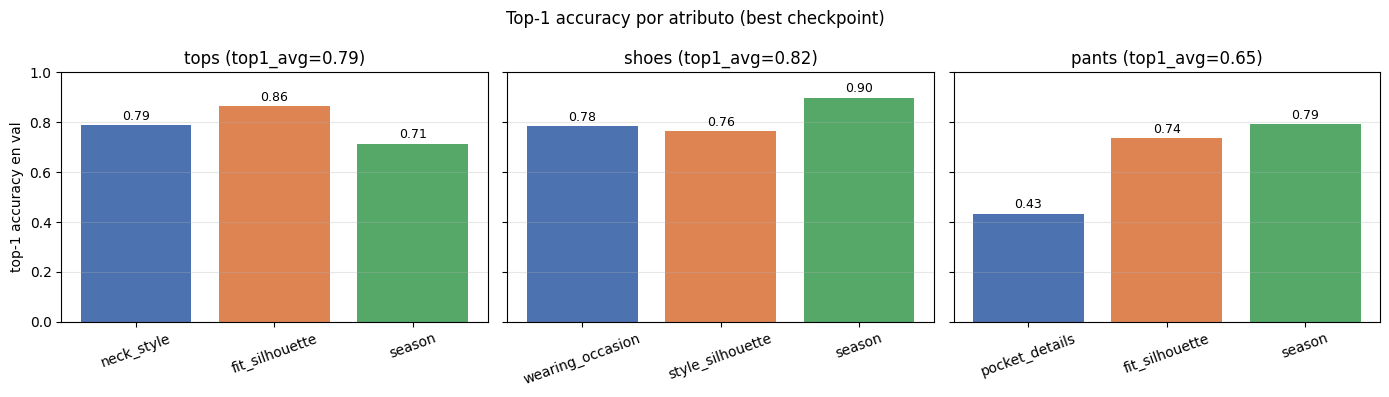

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (t, lf) in zip(axes, label_files.items()):
    top1 = lf["best_val"]["val_top1_per_group"]
    bars = ax.bar(top1.keys(), top1.values(), color=["#4c72b0", "#dd8452", "#55a868"])
    for b, v in zip(bars, top1.values()):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.2f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{t} (top1_avg={lf['best_val']['val_top1_avg']:.2f})")
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(alpha=0.3, axis="y")

axes[0].set_ylabel("top-1 accuracy en val")
fig.suptitle("Top-1 accuracy por atributo (best checkpoint)")
plt.tight_layout()
plt.show()


### F1 por clase (diagnóstico de fallas específicas)

El top-1 por atributo nos dice *cuán bien* le va al modelo en cada
atributo (p. ej. `pocket_details` 0.44 en pants), pero no *qué clases
concretas* están arrastrando ese promedio hacia abajo. Para decidir
intervenciones focalizadas (¿`pos_weight`? ¿más datos? ¿augmentation
por clase?) hace falta el detalle por clase.

La celda siguiente reporta las 3 mejores y 3 peores clases de cada
atributo, junto con el *support* (positivos en val): un F1 bajo con
*support* pequeño es ruido estadístico; un F1 bajo con *support* alto
es una falla real del modelo que vale la pena atacar.

Si el campo `val_f1_per_class_per_group` no está en el `.labels.json`,
hay que re-entrenar el modelo (es un agregado posterior al overnight).


In [62]:
def report_f1_per_class(labels: dict, k: int = 3) -> str:
    """Resumen legible: top-k y bottom-k clases por atributo."""
    bv = labels["best_val"]
    if "val_f1_per_class_per_group" not in bv:
        return "  (no disponible — re-entrenar el modelo para poblar este campo)"

    out = []
    for grupo, clases in bv["val_f1_per_class_per_group"].items():
        n = len(clases)
        ord_desc = sorted(clases.items(), key=lambda kv: kv[1]["f1"], reverse=True)
        out.append(f"\n  [{grupo}]  {n} clases")
        out.append(f"    TOP {k}:")
        for cls, d in ord_desc[:k]:
            out.append(f"      {cls:<28s} F1 = {d['f1']:.3f}   sup = {d['support']:>4d}")
        # Sólo mostrar BOTTOM si hay clases suficientes para que no se solape con TOP.
        if n > 2 * k:
            out.append(f"    BOTTOM {k}:")
            for cls, d in ord_desc[-k:]:
                out.append(f"      {cls:<28s} F1 = {d['f1']:.3f}   sup = {d['support']:>4d}")
    return "\n".join(out)


for t in PRODUCT_TYPES:
    print(f"\n══════════ {t.upper()} ══════════")
    print(report_f1_per_class(label_files[t]))



=== tops ===
      atributo  rango                 clase    f1  support_val
    neck_style    top             Crew-Neck 0.861          797
    neck_style    top         Collared-Neck 0.860          533
    neck_style    top           Square-Neck 0.842          124
    neck_style bottom  Mandarin-Collar-Neck 0.000            4
    neck_style bottom      Peter-Pan-Collar 0.000            2
    neck_style bottom          Pleated-Neck 0.000            4
fit_silhouette    top           Relaxed-Fit 0.932         2340
fit_silhouette    top                Fitted 0.794          325
fit_silhouette    top              Slim-Fit 0.749           80
fit_silhouette bottom              Slim-Fit 0.749           80
fit_silhouette bottom          Tailored-Fit 0.636          495
fit_silhouette bottom           Classic-Fit 0.167            8
        season    top                  Fall 0.765         1031
        season    top     Tropical-Vacation 0.741          888
        season    top                Spri

#### Lectura del F1 por clase (los tres modelos)

> ⚠️ La celda de código de arriba lee del `.labels.json` actual en disco,
> que contiene los modelos **post-E7 (con pos_weight)**. Las tablas que
> siguen describen el **estado pre-E7 (baseline sin pos_weight)** — fue
> el diagnóstico que motivó E7. Para ver cómo cambiaron las clases con
> pos_weight, ir a la sección **E7** (tablas comparativas
> "antes / después / Δ").

##### `tops` (estado pre-E7)

| Atributo | Clases | Mejor (F1, sup) | Peor con sup útil (F1, sup) | Comentario |
|---|---:|---|---|---|
| `neck_style` | 26 | Collared-Neck (0.88, 533) | Mock-Neck (0.48, 74) | cola larga clásica: 7 clases con f1=0, todas con sup ≤18 |
| `fit_silhouette` | 5 | Relaxed-Fit (0.94, 2340) | Tailored-Fit (0.64, 495) | la 2da clase más común no se aprende bien |
| `season` | 4 | Fall (0.73, 1031) | Cold_Weather-Vacation (0.51, 123) | ninguna clase pasa de 0.73 pese a sup ≥123 — season visualmente ambiguo en tops |

##### `shoes` (estado pre-E7)

| Atributo | Clases | Mejor (F1, sup) | Peor con sup útil (F1, sup) | Comentario |
|---|---:|---|---|---|
| `wearing_occasion` | 13 | Day-Party (0.84, 604) | Formal (0.29, 15), Pool/Spa (0.42, 24) | mayoritarias OK; clases medias-chicas con F1 muy bajo |
| `style_silhouette` | 30 | Loafers (0.92, 243) | Espadrilles (0.43, 19), Mules (0.58, 47) | top excelente; bottom = sup muy bajo (≤3) y algunos intermedios débiles |
| `season` | 4 | Fall (0.96, 1301) | Spring (0.26, 65) | falla real: el modelo confunde primavera con otoño en zapatos |

##### `pants` (estado pre-E7)

| Atributo | Clases | Mejor (F1, sup) | Peor con sup útil (F1, sup) | Comentario |
|---|---:|---|---|---|
| `pocket_details` | 11 | Traditional-Five-Pocket (0.59, 52) | Slant-Pocket (0.08, 64), Welt-Pocket (0.23, 70) | la mayoritaria `Pockets` (0.48, 264) también falla; cola con sup ≤9 en cero |
| `fit_silhouette` | 5 | Regular-Fit-Pant (0.83, 405) | Loose-Fit-Pant (0.56, 102) | `Fitted` (sup=13) en F1=0: el modelo lo confunde con Regular o Slim |
| `season` | 4 | Fall (0.90, 391) | Tropical-Vacation (0.42, 63) | pantalones tropicales visualmente similares a pantalones de cualquier estación |

##### Patrones globales

| # | Patrón | Implicancia |
|---|---|---|
| 1 | **Cola larga**: clases con sup ≤15 → f1≈0 en los 3 modelos sin importar el atributo | irrecuperables con `pos_weight`; sólo más datos las salvan |
| 2 | **Clases con sup 50-500 que fallan** (Tailored-Fit, Pool/Spa, Slant-Pocket, etc.) | candidatas directas para `pos_weight` |
| 3 | **`season` en tops** es estructuralmente difícil: ninguna clase pasa de 0.73 aunque todas tengan sup ≥123 | no se arregla con `pos_weight` — problema de información en la imagen |
| 4 | **`pocket_details` es el atributo más débil del sistema** (top1=0.44) | la mayoritaria `Pockets` (genérica, ambigua) tira el promedio hacia abajo |

##### Implicancia para E7 (`pos_weight`)

| Tipo | Clases que probablemente E7 mueve | Esperado en `f1_macro` |
|---|---|---:|
| tops  | `Tailored-Fit`, `Cold_Weather-Vacation`, varios `neck_style` medios (Mock-Neck, Band-Collar) | +2 a +4 pts |
| shoes | `Pool/Spa`, `Formal`, `Spring`, varios silhouettes medios | +3 a +5 pts |
| pants | `Slant-Pocket`, `Welt-Pocket`, `Patch-Pocket`, `Tropical-Vacation`, `Fitted` | +3 a +5 pts |

Probable trade-off: `f1_micro` baja 1-3 pts en cada uno (clases
mayoritarias se ponderan menos). El movimiento de la métrica de
selección (`f1_macro`) compensa.

> **Lo que efectivamente pasó al correr E7** (resumen, ver E7 para detalle):
>
> | Métrica | Δ promedio |
> |---|---|
> | `f1_macro` | **+6 pts** en los tres (cota alta del rango estimado) |
> | `f1_micro` | se mantuvo |
> | `subset_acc` | **−6 a −10 pts** ← el costo real estuvo acá, no en `f1_micro` |
>
> Clases medias dispararon: Moccasin 0.17→0.50, Spring (shoes) 0.26→0.49, Welt-Pocket 0.23→0.39.


### `val_loss` vs `val_f1_macro` por epoch

Esta visualización muestra que las dos curvas no necesariamente
co-evolucionan. En `tops`, `val_loss` mínimo está en epoch 3 mientras
`f1_macro` sigue mejorando hasta epoch 9. Esa fue la observación que
motivó el aprendizaje de E5.


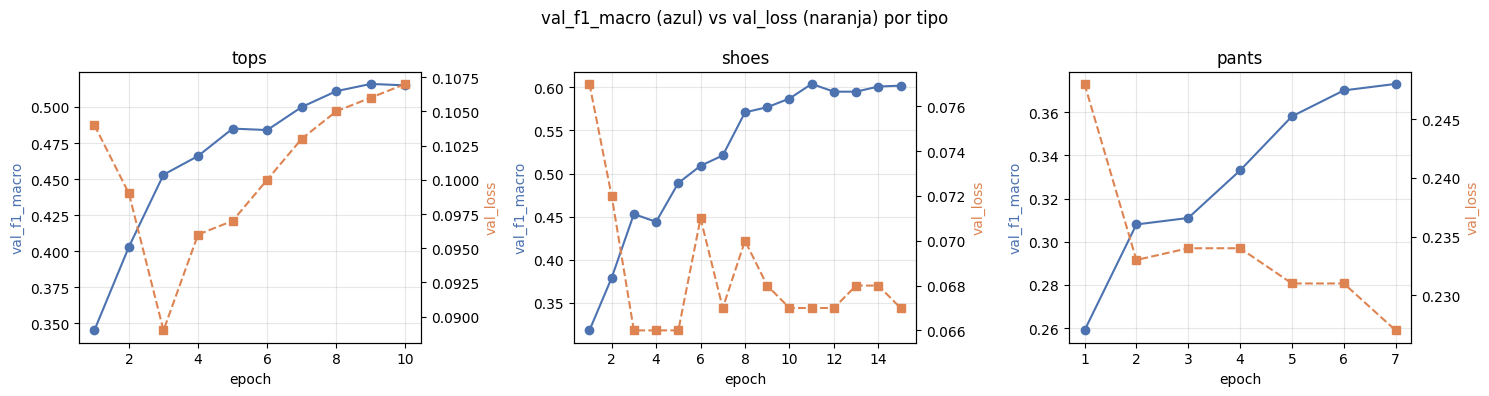

In [63]:
val_loss_curves = {
    "tops":  [0.104, 0.099, 0.089, 0.096, 0.097, 0.100, 0.103, 0.105, 0.106, 0.107],
    "shoes": [0.077, 0.072, 0.066, 0.066, 0.066, 0.071, 0.067, 0.070, 0.068, 0.067, 0.067, 0.067, 0.068, 0.068, 0.067],
    "pants": [0.248, 0.233, 0.234, 0.234, 0.231, 0.231, 0.227],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (t, f1) in zip(axes, curves.items()):
    epochs = list(range(1, len(f1) + 1))
    ax2 = ax.twinx()
    ax.plot(epochs, f1, "o-", color="#4c72b0", label="val_f1_macro")
    ax2.plot(epochs, val_loss_curves[t], "s--", color="#dd8452", label="val_loss")
    ax.set_xlabel("epoch")
    ax.set_ylabel("val_f1_macro", color="#4c72b0")
    ax2.set_ylabel("val_loss", color="#dd8452")
    ax.set_title(t)
    ax.grid(alpha=0.3)

fig.suptitle("val_f1_macro (azul) vs val_loss (naranja) por tipo")
plt.tight_layout()
plt.show()


## Reproducción

### Artefactos en disco


In [64]:
artifacts = []
for f in sorted(TORCH_STATE.glob("multilabel_classifier_*")):
    artifacts.append({
        "archivo": f.name,
        "tamaño (MB)": round(f.stat().st_size / 1024**2, 2),
    })

pd.DataFrame(artifacts)


,archivo,tamaño (MB)
0,multilabel_classifier_pants_v1.labels.json,0.00
1,multilabel_classifier_pants_v1.pth,42.75
2,multilabel_classifier_shoes_v1.labels.json,0.01
3,multilabel_classifier_shoes_v1.pth,42.81
4,multilabel_classifier_tops_v1.labels.json,0.01
5,multilabel_classifier_tops_v1.pth,42.78


### Estructura del `.labels.json`

Lo que la inferencia carga junto con el `.pth`:


In [65]:
sample = label_files["tops"]
display_view = json.loads(json.dumps(sample))  # deep copy
for g in display_view["groups"]:
    g["classes"] = g["classes"][:5] + (["..."] if len(sample["groups"][0]["classes"]) > 5 else [])
print(json.dumps(display_view, indent=2, ensure_ascii=False))


{
  "product_type": "tops",
  "num_logits": 35,
  "image_size": 224,
  "normalize_mean": [
    0.485,
    0.456,
    0.406
  ],
  "normalize_std": [
    0.229,
    0.224,
    0.225
  ],
  "min_samples_per_class": 20,
  "groups": [
    {
      "name": "neck_style",
      "start": 0,
      "end": 26,
      "classes": [
        "Asymmetrical-Collar",
        "Band-Collar",
        "Boat-Neck",
        "Collared-Neck",
        "Cowl-Neck",
        "..."
      ]
    },
    {
      "name": "fit_silhouette",
      "start": 26,
      "end": 31,
      "classes": [
        "Classic-Fit",
        "Fitted",
        "Relaxed-Fit",
        "Slim-Fit",
        "Tailored-Fit",
        "..."
      ]
    },
    {
      "name": "season",
      "start": 31,
      "end": 35,
      "classes": [
        "Cold_Weather-Vacation",
        "Fall",
        "Spring",
        "Tropical-Vacation",
        "..."
      ]
    }
  ],
  "best_epoch": 9,
  "best_val": {
    "val_loss": 0.3551553166829623,
    "val_f1_micr

### Comandos

Con el venv del API activado (`deep-tagger-api/.venv/Scripts/Activate.ps1`):

```powershell
# Entrenar uno por uno con la config actual de cada tipo:
python deep_learning/train_multilabel.py --product-type tops  --device cuda --batch-size 128 --num-workers 4 --max-samples 0 --epochs 10
python deep_learning/train_multilabel.py --product-type shoes --device cuda --batch-size 128 --num-workers 4 --max-samples 0 --epochs 15
python deep_learning/train_multilabel.py --product-type pants --device cuda --batch-size 128 --num-workers 4 --max-samples 0 --epochs 15

# O lanzar los tres con captura de log:
.\scripts\overnight_training.ps1
```

CLI completo del script:

```
--product-type {tops,shoes,pants}    requerido
--device {cpu,cuda,auto}             default: auto
--max-samples N                      default: 10000  (0 = sin cap)
--epochs N                           default: 10
--batch-size N                       default: 64
--lr X                               default: 3e-4
--num-workers N                      default: 0  (Windows-safe)
--seed N                             default: 42
--pretrained / --no-pretrained       default: --pretrained
```

**Reproducibilidad estricta:** la seed `42` está fijada en `random`,
`numpy`, `torch` y `torch.cuda`, pero los kernels de cuDNN no son
bit-exactos. Diferencias de ±1 pt en `f1_macro` entre corridas idénticas
son normales. Si hace falta reproducibilidad estricta, agregar
`torch.backends.cudnn.deterministic = True` (con costo ~10-20% en
velocidad).
